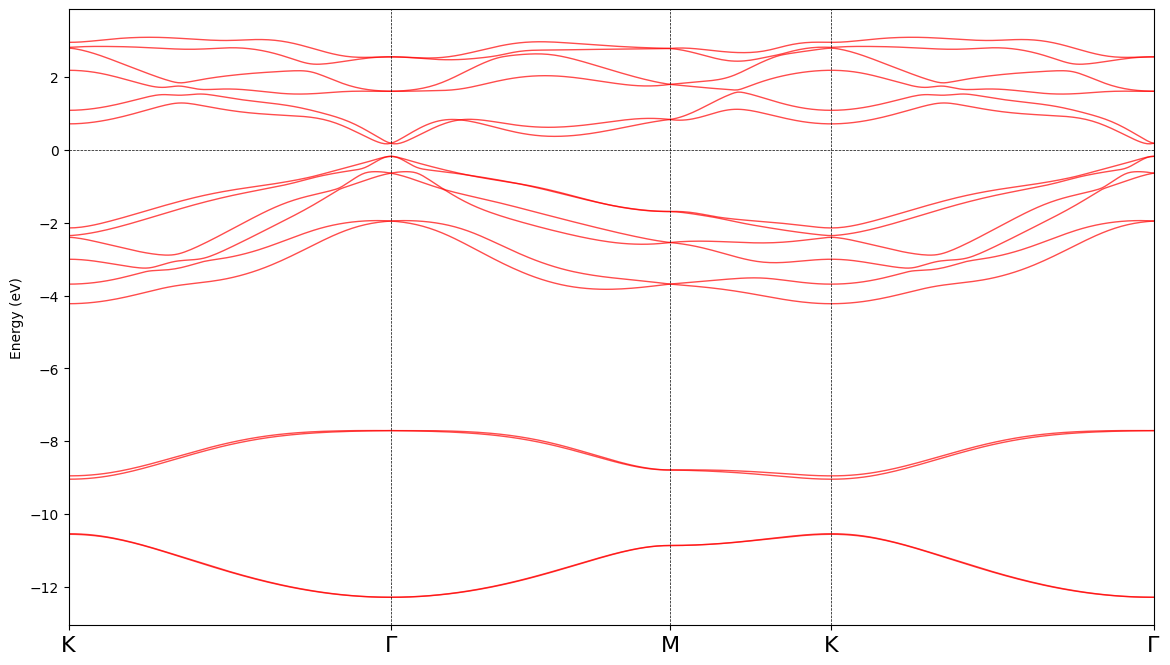

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np


data = np.loadtxt('wannier_band.dat')

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))

fermi_level = -0.4737

high_symmetry_points = [0, 0.9795612826, 1.8278947211, 2.3176753625, 3.2972366451]  
high_symmetry_labels = [ 'K', r'$\Gamma$','M', 'K', r'$\Gamma$']

plt.figure(figsize=(14, 8))

for band in range(len(bands)):
    plt.plot(k, bands[band, :]-fermi_level, linewidth=1, alpha=0.7, color='red')
plt.xlim(min(k), max(k))

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel("Energy (eV)")
#plt.ylim(-5,5)
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2025-11-06 21:46:48,099                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(8, 27, 2)                                  |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

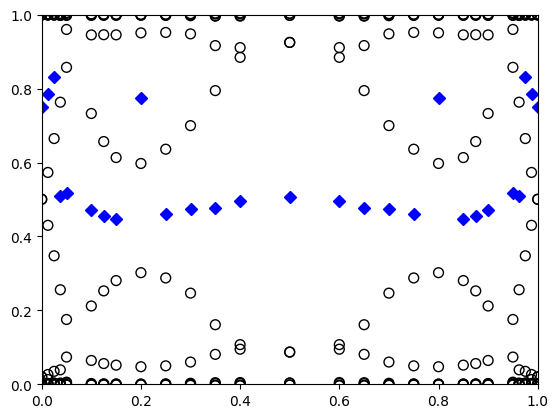

In [3]:
import z2pack
import tbmodels

model = tbmodels.Model.from_wannier_files(hr_file='wannier_hr.dat')
system = z2pack.tb.System(model)
result = z2pack.surface.run(
    system=system,
    surface=lambda t1, t2: [t1,t2,0],
)
   # Prints the Chern number
print(z2pack.invariant.chern(result))
z2pack.plot.wcc(result)
plt.show()      # Prints the Z2 invariant

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

data = np.loadtxt("Berrycurvature.dat")

kx = data[:, 0]   
ky = data[:, 1]   
Wx = data[:, 2] 
Wy = data[:, 3]   
Wz = data[:, 4]   

kx_unique = np.unique(kx)
ky_unique = np.unique(ky)
nkx, nky = len(kx_unique), len(ky_unique)
print(nkx, nky)
# Reshape for 2D integration
Oz_grid = Wz.reshape((nkx, nky))

# === Compute dk spacing ===
dkx = np.abs(kx_unique[1] - kx_unique[0])
dky = np.abs(ky_unique[1] - ky_unique[0])

# === Integrate over the Brillouin zone ===
integral = np.sum(Oz_grid) * dkx * dky

# === Chern number ===
Chern = integral / (2 * np.pi)

print(f"Chern number ≈ {Chern:.4f}")



101 201


ValueError: cannot reshape array of size 10201 into shape (101,201)